# Model Evaluation
Run `test_all.sh` to generate the evaluation metrics for all models.

In [ ]:
!bash test_all.sh

## Compare Accuracies
Plot the Character Error Rate (CER) and Word Error Rate (WER) across all models.

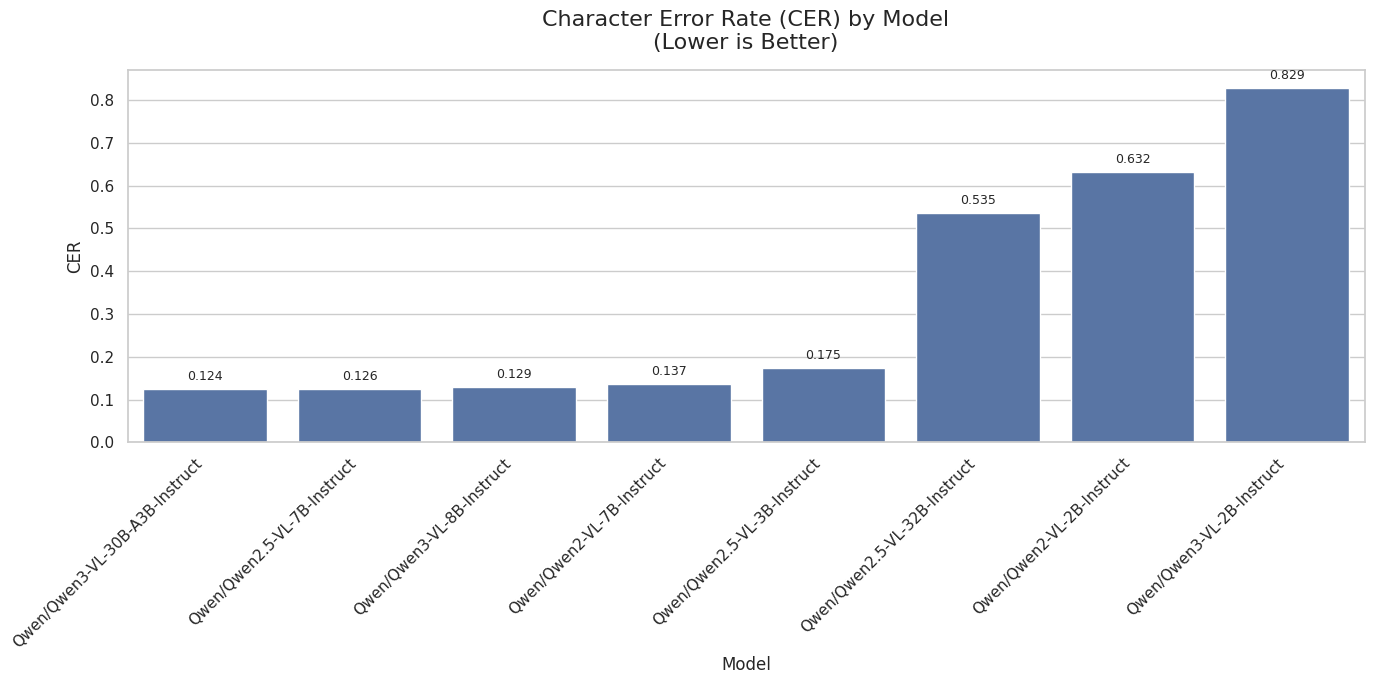

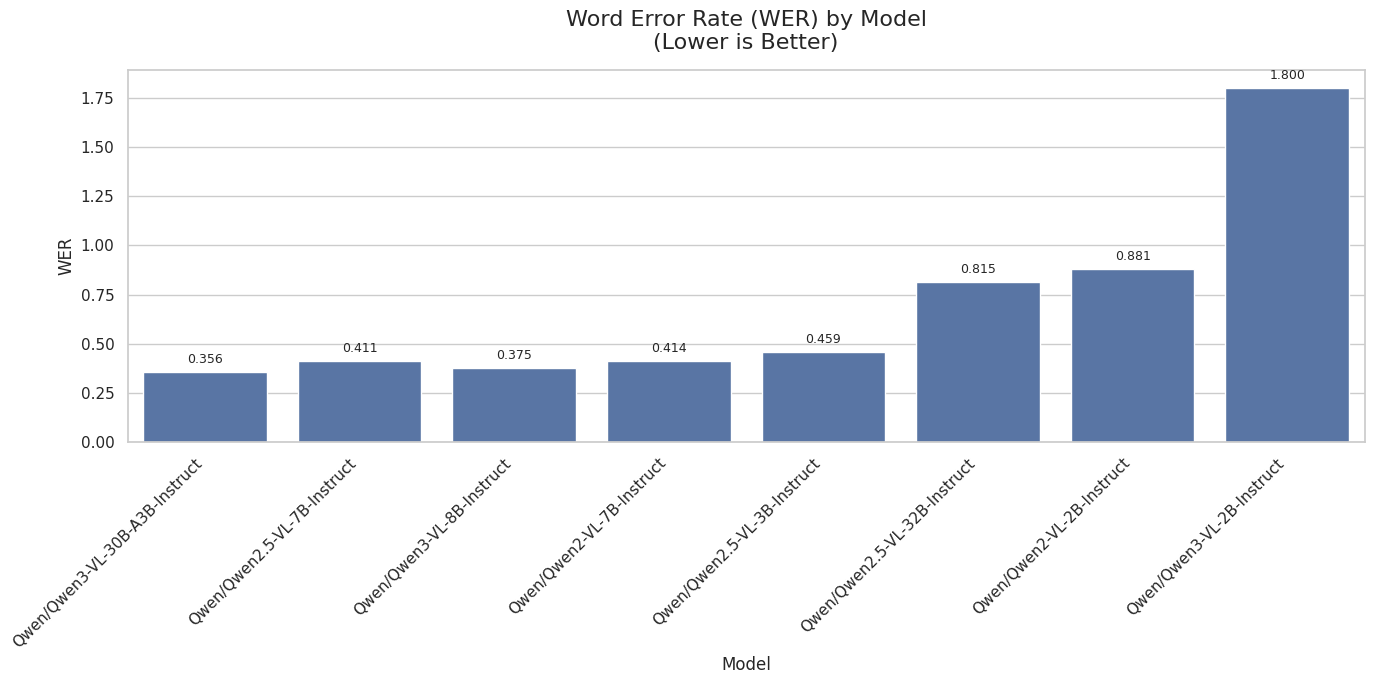

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

outputs_dir = 'outputs'
results = []

# Read all json output files
if os.path.exists(outputs_dir):
    for filename in os.listdir(outputs_dir):
        if filename.endswith('.json'):
            filepath = os.path.join(outputs_dir, filename)
            with open(filepath, 'r') as f:
                try:
                    data = json.load(f)
                    cer = data.get('cer', None)
                    wer = data.get('wer', None)
                    # Only append rows with valid CER and WER values
                    if cer is not None and wer is not None:
                        results.append({
                            'Model': data.get('model_id', 'Unknown'),
                            'Dataset': data.get('data_dir', 'Unknown'),
                            'CER': cer,
                            'WER': wer
                        })
                except json.JSONDecodeError:
                    print(f"Warning: Could not parse {filename}")

df = pd.DataFrame(results)
# Filter to only include data_alltest
df = df[df['Dataset'] == 'data_alltest']
df = df.sort_values(by=['CER']).reset_index(drop=True)

if not df.empty:
    # Aesthetics improvements
    sns.set_theme(style="whitegrid", palette="deep")
    
    def plot_metric(metric, title):
        plt.figure(figsize=(14, 7))
        # Remove hue since we only have one dataset
        ax = sns.barplot(data=df, x='Model', y=metric, color=sns.color_palette("deep")[0])
        plt.title(title, fontsize=16, pad=15)
        plt.xticks(rotation=45, ha='right', fontsize=11)
        plt.yticks(fontsize=11)
        plt.ylabel(metric, fontsize=12)
        plt.xlabel('Model', fontsize=12)
        
        # Add value labels on bars for valid data points only
        for p in ax.patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:  # Avoid annotating invalid or zero values
                ax.annotate(format(height, '.3f'), 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha = 'center', va = 'center', 
                            xytext = (0, 9), 
                            textcoords = 'offset points',
                            fontsize=9)
                            
        plt.tight_layout()
        plt.show()

    plot_metric('CER', 'Character Error Rate (CER) by Model\n(Lower is Better)')
    plot_metric('WER', 'Word Error Rate (WER) by Model\n(Lower is Better)')
else:
    print("No evaluation results found for 'data_alltest' in the 'outputs' directory.")

## Accuracy vs Model Size
Plot the relationship between model size (in billions of parameters) and accuracy (1 - CER).

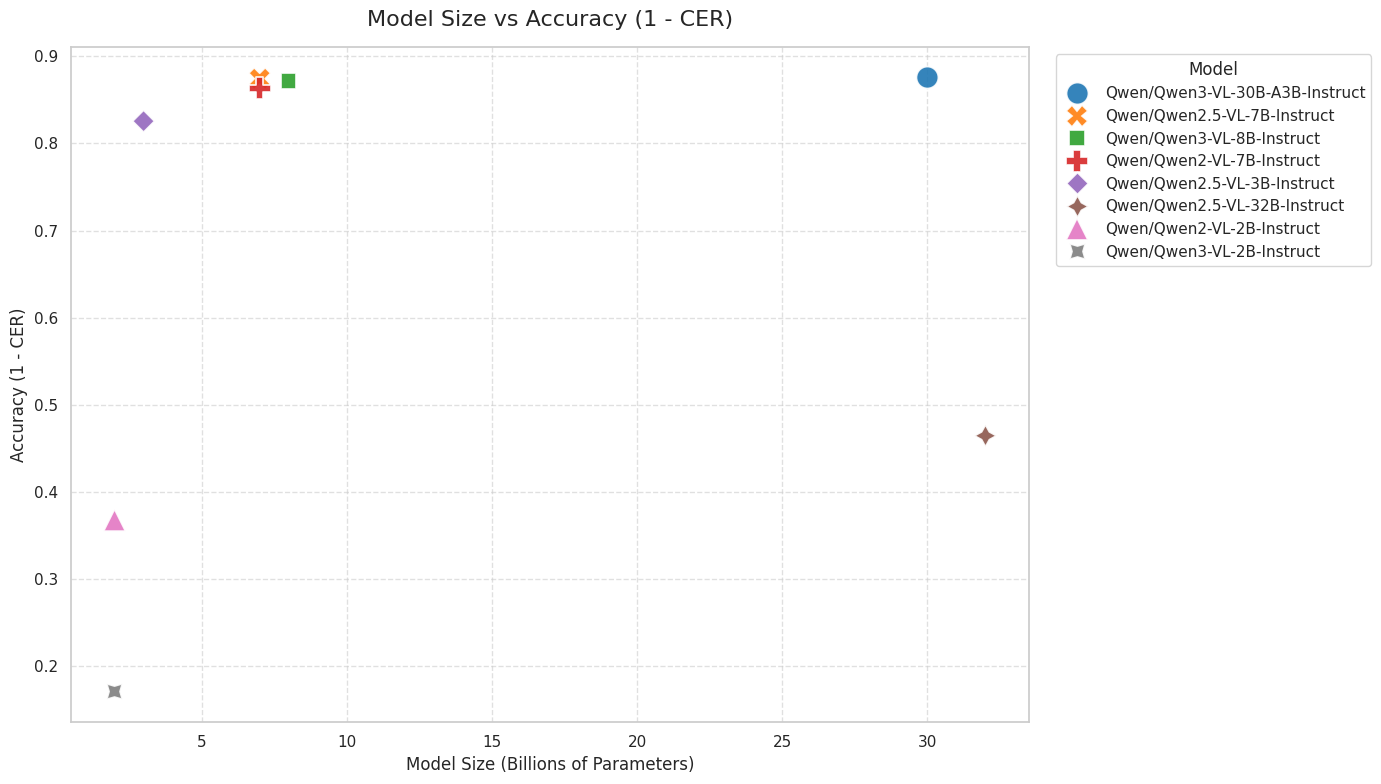

In [6]:
def extract_model_size(model_name):
    match = re.search(r'(\d+(?:\.\d+)?)(?:B)', model_name)
    if match:
        return float(match.group(1))
    return None

if not df.empty:
    size_df = df.copy()
    size_df['Size (B)'] = size_df['Model'].apply(extract_model_size)
    size_df['Accuracy (1-CER)'] = 1 - size_df['CER']
    size_df = size_df.dropna(subset=['Size (B)'])
    
    if not size_df.empty:
        plt.figure(figsize=(14, 8))
        
        # Use hue and style by 'Model' to give each point a different color and marker.
        # We don't clip the axes -- matplotlib will auto-scale to show negative accuracy if CER > 1.
        ax = sns.scatterplot(data=size_df, x='Size (B)', y='Accuracy (1-CER)', 
                        hue='Model', style='Model', s=250, alpha=0.9, palette='tab10')
        
        plt.title('Model Size vs Accuracy (1 - CER)', fontsize=16, pad=15)
        plt.xlabel('Model Size (Billions of Parameters)', fontsize=12)
        plt.ylabel('Accuracy (1 - CER)', fontsize=12)
        
        plt.grid(True, linestyle='--', alpha=0.6)
        
        # Move the legend outside the plot so labels don't overlap the dots
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title='Model', frameon=True)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Could not extract model sizes from the model names.")
else:
    print("No data available for size vs accuracy plot.")

## Fine-Tune Models
Run the `finetune.py` script to fine-tune specific models on the `data/IEHHR` dataset.

In [ ]:
# Example: Fine-tune Qwen2.5-VL-7B-Instruct on data/IEHHR
!python finetune.py \
    --model "Qwen/Qwen2.5-VL-7B-Instruct" \
    --annotation_file "data/IEHHR/train_annotations.jsonl" \
    --base_image_dir "data/IEHHR/" \
    --output_dir "./checkpoints/qwen2.5-7B-iehhr" \
    --epochs 3 \
    --batch_size 2 \
    --grad_accum_steps 8 \
    --learning_rate 2e-4

In [ ]:
# Example: Fine-tune Qwen3-VL-2B-Instruct on data/IEHHR
!python finetune.py \
    --model "Qwen/Qwen3-VL-2B-Instruct" \
    --annotation_file "data/IEHHR/train_annotations.jsonl" \
    --base_image_dir "data/IEHHR/" \
    --output_dir "./checkpoints/qwen3-2B-iehhr" \
    --epochs 3 \
    --batch_size 2 \
    --grad_accum_steps 8 \
    --learning_rate 2e-4

## Compare Base vs Fine-Tuned Models
Plot the Character Error Rate (CER) and Word Error Rate (WER) comparing base models with their fine-tuned counterparts.

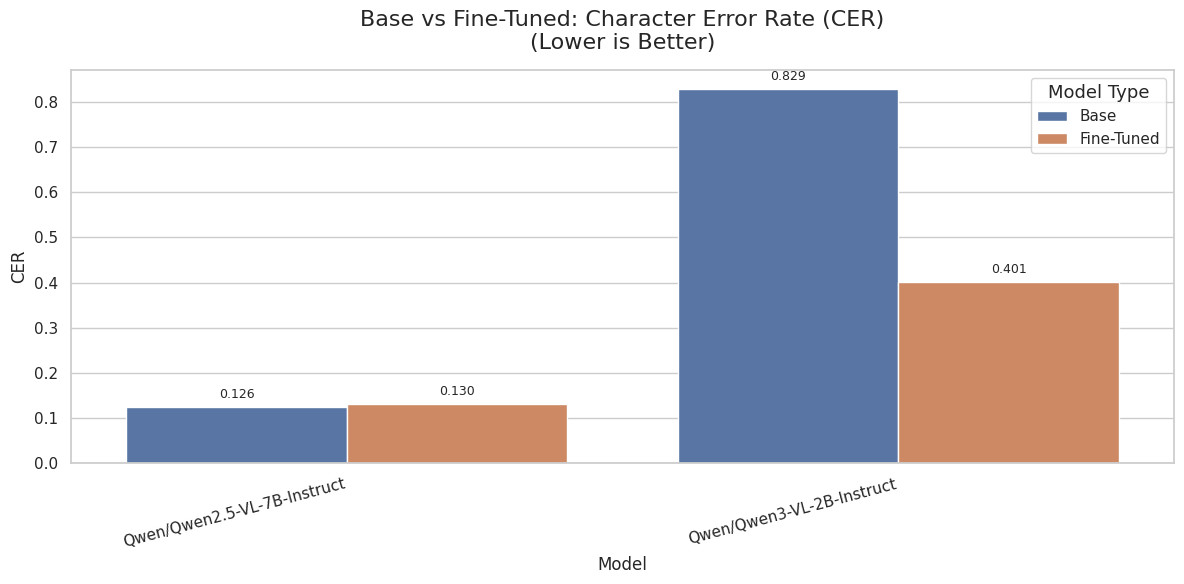

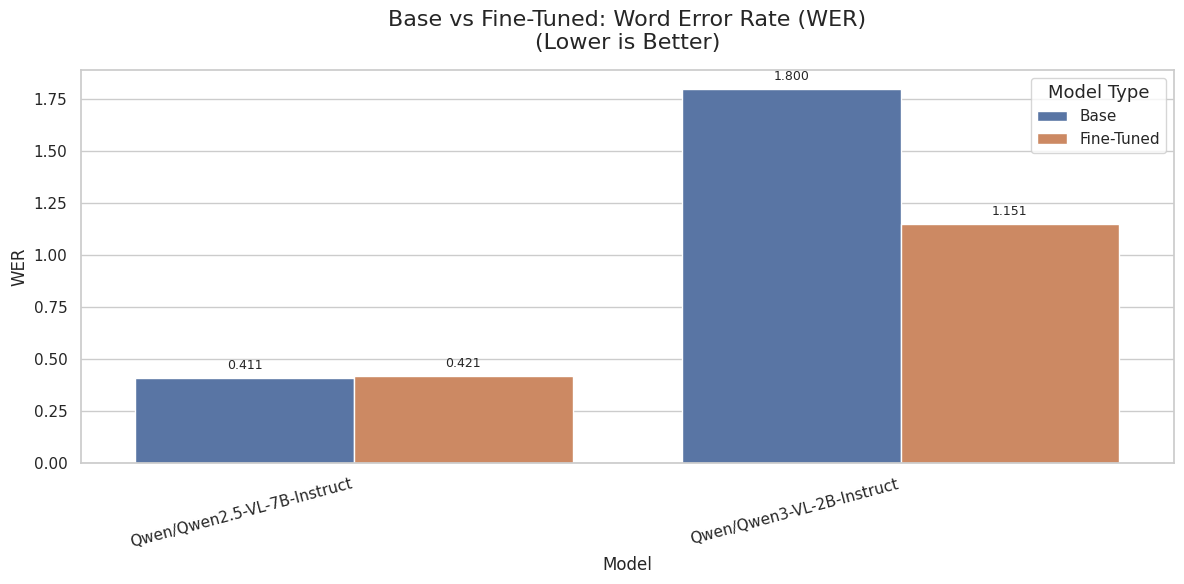

In [7]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

outputs_dir = 'outputs'
finetuned_dir = 'finetuned_outputs'

base_results = []
finetuned_results = []

# Read finetuned results first to know which models to compare
if os.path.exists(finetuned_dir):
    for filename in os.listdir(finetuned_dir):
        if filename.endswith('.json'):
            filepath = os.path.join(finetuned_dir, filename)
            with open(filepath, 'r') as f:
                try:
                    data = json.load(f)
                    cer = data.get('cer', None)
                    wer = data.get('wer', None)
                    if cer is not None and wer is not None and data.get('data_dir') == 'data_alltest':
                        finetuned_results.append({
                            'Model': data.get('model_id', 'Unknown'),
                            'Type': 'Fine-Tuned',
                            'CER': cer,
                            'WER': wer
                        })
                except json.JSONDecodeError:
                    print(f"Warning: Could not parse {filename}")

finetuned_models = [res['Model'] for res in finetuned_results]

# Read base results for the models that have finetuned counterparts
if os.path.exists(outputs_dir) and finetuned_models:
    for filename in os.listdir(outputs_dir):
        if filename.endswith('.json'):
            filepath = os.path.join(outputs_dir, filename)
            with open(filepath, 'r') as f:
                try:
                    data = json.load(f)
                    model_id = data.get('model_id', 'Unknown')
                    cer = data.get('cer', None)
                    wer = data.get('wer', None)
                    if model_id in finetuned_models and cer is not None and wer is not None and data.get('data_dir') == 'data_alltest':
                        base_results.append({
                            'Model': model_id,
                            'Type': 'Base',
                            'CER': cer,
                            'WER': wer
                        })
                except json.JSONDecodeError:
                    print(f"Warning: Could not parse {filename}")

# Combine and plot
all_results = base_results + finetuned_results
df_compare = pd.DataFrame(all_results)

if not df_compare.empty:
    # Sort to ensure consistent ordering
    df_compare = df_compare.sort_values(by=['Model', 'Type']).reset_index(drop=True)
    
    sns.set_theme(style="whitegrid", palette="deep")
    
    def plot_comparison(metric, title):
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(data=df_compare, x='Model', y=metric, hue='Type')
        plt.title(title, fontsize=16, pad=15)
        plt.xticks(rotation=15, ha='right', fontsize=11)
        plt.yticks(fontsize=11)
        plt.ylabel(metric, fontsize=12)
        plt.xlabel('Model', fontsize=12)
        plt.legend(title='Model Type', title_fontsize='13', fontsize='11')
        
        # Add value labels on bars
        for p in ax.patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:
                ax.annotate(format(height, '.3f'), 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha = 'center', va = 'center', 
                            xytext = (0, 9), 
                            textcoords = 'offset points',
                            fontsize=9)
                            
        plt.tight_layout()
        plt.show()

    plot_comparison('CER', 'Base vs Fine-Tuned: Character Error Rate (CER)\n(Lower is Better)')
    plot_comparison('WER', 'Base vs Fine-Tuned: Word Error Rate (WER)\n(Lower is Better)')
else:
    print("No matching base and fine-tuned results found for comparison.")